**Import Libraries**

In [62]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

from imblearn.over_sampling import SMOTE
from collections import Counter

import seaborn as sns
import matplotlib.pyplot as plt

**Load the Clean Dataset**

In [63]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [68]:
X_train = np.load("/content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/X_train.npy", allow_pickle=True)
X_val = np.load("/content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/X_val.npy", allow_pickle=True)
X_test = np.load("/content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/X_test.npy", allow_pickle=True)

y_train = np.load("/content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/y_train.npy", allow_pickle=True)
y_val = np.load("/content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/y_val.npy", allow_pickle=True)
y_test = np.load("/content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/y_test.npy", allow_pickle=True)

In [69]:
df = pd.read_csv("//content/drive/MyDrive/Heart Diseases - AI Project/datasets/Processed_Datasets/stroke_clean_Fin.csv")

df.head()

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Never_worked,work_type_Private,...,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,risk_score,age_group_Adult,age_group_Middle_Aged,age_group_Elderly,bmi_category_Normal,bmi_category_Overweight,bmi_category_Obese
0,1,67.0,0,1,1,228.69,36.6,1,0.0,1.0,...,1.0,0.0,0.0,113.576,False,False,True,False,False,True
1,1,80.0,0,1,1,105.92,32.5,1,0.0,1.0,...,0.0,1.0,0.0,68.368,False,False,True,False,False,True
2,0,49.0,0,0,1,171.23,34.4,1,0.0,1.0,...,0.0,0.0,1.0,83.192,True,False,False,False,False,True
3,0,79.0,1,0,1,174.12,24.0,1,0.0,0.0,...,0.0,1.0,0.0,95.348,False,False,True,True,False,False
4,1,81.0,0,0,1,186.21,29.0,1,0.0,1.0,...,1.0,0.0,0.0,98.784,False,False,True,False,True,False


**Define Features and Target**

In [70]:
X = df.drop("stroke", axis=1)
y = df["stroke"]

**Train-Test split check from preprocessing**

In [71]:
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

print("Train distribution:", Counter(y_train))

Train: (2945, 22)
Validation: (982, 22)
Test: (982, 22)
Train distribution: Counter({np.int64(0): 2820, np.int64(1): 125})


**Check Class Balance AND Smote Vs Class Weight AND Choosing the best model**

In [72]:
print("Original training distribution:", Counter(y_train))

Original training distribution: Counter({np.int64(0): 2820, np.int64(1): 125})


SMOTE models

In [73]:
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("After SMOTE:", Counter(y_train_res))

models_smote = {
    "LogReg_SMOTE": LogisticRegression(max_iter=1000),
    "RF_SMOTE": RandomForestClassifier(random_state=42),
    "DT_SMOTE": DecisionTreeClassifier(random_state=42),
    "SVM_SMOTE": SVC(probability=True, random_state=42)
}

results_smote = []
trained_models_smote = {}

After SMOTE: Counter({np.int64(0): 2820, np.int64(1): 2820})


SMOTE training

In [74]:
for name, model in models_smote.items():

    model.fit(X_train_res, y_train_res)
    y_pred = model.predict(X_test)

    trained_models_smote[name] = model

    results_smote.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4)
    })

results_smote_df = pd.DataFrame(results_smote)
print(results_smote_df)

          Model  Accuracy  Precision  Recall      F1
0  LogReg_SMOTE    0.7413     0.1131  0.7381  0.1962
1      RF_SMOTE    0.9338     0.1034  0.0714  0.0845
2      DT_SMOTE    0.9094     0.1270  0.1905  0.1524
3     SVM_SMOTE    0.8513     0.0938  0.2857  0.1412


CLASS WEIGHT models


In [75]:
models_weight = {
    "LogReg_Weight": LogisticRegression(class_weight='balanced', max_iter=1000),
    "RF_Weight": RandomForestClassifier(class_weight='balanced', random_state=42),
    "DT_Weight": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "SVM_Weight": SVC(class_weight='balanced', probability=True, random_state=42)
}

results_weight = []
trained_models_weight = {}

CLASS WEIGHT training

In [76]:
for name, model in models_weight.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    trained_models_weight[name] = model

    results_weight.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred, zero_division=0), 4),
        "Recall": round(recall_score(y_test, y_pred, zero_division=0), 4),
        "F1": round(f1_score(y_test, y_pred, zero_division=0), 4)
    })

results_weight_df = pd.DataFrame(results_weight)
print(results_weight_df)

           Model  Accuracy  Precision  Recall      F1
0  LogReg_Weight    0.7475     0.1213  0.7857  0.2102
1      RF_Weight    0.9562     0.0000  0.0000  0.0000
2      DT_Weight    0.9175     0.0667  0.0714  0.0690
3     SVM_Weight    0.8045     0.1053  0.4762  0.1724


Final Comparison

In [77]:
final_df = pd.concat([results_smote_df, results_weight_df])

print("\n=== FINAL COMPARISON ===\n")
print(final_df.sort_values(by="F1", ascending=False))


=== FINAL COMPARISON ===

           Model  Accuracy  Precision  Recall      F1
0  LogReg_Weight    0.7475     0.1213  0.7857  0.2102
0   LogReg_SMOTE    0.7413     0.1131  0.7381  0.1962
3     SVM_Weight    0.8045     0.1053  0.4762  0.1724
2       DT_SMOTE    0.9094     0.1270  0.1905  0.1524
3      SVM_SMOTE    0.8513     0.0938  0.2857  0.1412
1       RF_SMOTE    0.9338     0.1034  0.0714  0.0845
2      DT_Weight    0.9175     0.0667  0.0714  0.0690
1      RF_Weight    0.9562     0.0000  0.0000  0.0000


Select base model

In [78]:
best_model_name = final_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]

print("Best model:", best_model_name)

if "SMOTE" in best_model_name:
    best_model = trained_models_smote[best_model_name]
else:
    best_model = trained_models_weight[best_model_name]

Best model: LogReg_Weight


Final Evaluation

In [79]:
y_pred_test = best_model.predict(X_test)

print("\nFinal Test Results:\n")
print(classification_report(y_test, y_pred_test, zero_division=0))


Final Test Results:

              precision    recall  f1-score   support

           0       0.99      0.75      0.85       940
           1       0.12      0.79      0.21        42

    accuracy                           0.75       982
   macro avg       0.55      0.77      0.53       982
weighted avg       0.95      0.75      0.82       982



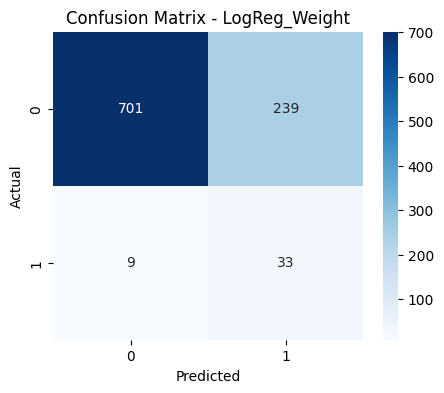

In [80]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()